# Tech Challenge - Modelo Preditivo Ibovespa
## Objetivo: Criar modelo com 75% de precisão para prever direção do preço (subir/descer)

### Algoritmos: XGBoost e Random Forest
### Dados: Ibovespa (ibov_index.csv)


In [1]:
# Importando bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_curve
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Configurações para visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


In [2]:
# Carregando os dados
df = pd.read_csv('IbovDef.csv')

print("Informações básicas dos dados:")
print(f"Shape: {df.shape}")
print(f"\nPrimeiras 5 linhas:")
print(df.head())

print(f"\nTipos de dados:")
print(df.dtypes)



Informações básicas dos dados:
Shape: (2482, 7)

Primeiras 5 linhas:
         Data   Último  Abertura   Máxima   Mínima   Vol.    Var%
0  06.10.2025  143.608   144.202  144.532  143.376  5,98B  -0,41%
1  03.10.2025  144.201   143.950  144.518  143.676  6,18B   0,17%
2  02.10.2025  143.950   145.517  145.621  143.635  7,25B  -1,08%
3  01.10.2025  145.517   146.237  146.879  145.193  8,34B  -0,49%
4  30.09.2025  146.237   146.337  147.578  145.774  9,48B  -0,07%

Tipos de dados:
Data         object
Último      float64
Abertura    float64
Máxima      float64
Mínima      float64
Vol.         object
Var%         object
dtype: object


In [3]:
# Limpeza e preparação dos dados
print("Tipos de dados originais:")
print(df.dtypes)
print(f"\nPrimeiras 3 linhas:")
print(df.head(3))

# Convertendo a coluna Data para datetime
df['Data'] = pd.to_datetime(df['Data'], format='%d.%m.%Y')

# Verificando se as colunas são strings ou já numéricas
print(f"\nVerificando tipos após conversão de data:")
print(df.dtypes)

# Convertendo colunas numéricas - verificando se são strings primeiro
numeric_columns = ['Último', 'Abertura', 'Máxima', 'Mínima']
for col in numeric_columns:
    if df[col].dtype == 'object':  # Se for string
        df[col] = df[col].str.replace(',', '.').astype(float)
    else:  # Se já for numérico
        df[col] = df[col].astype(float)

# Convertendo volume - tratando diferentes sufixos (B, M, K)
if df['Vol.'].dtype == 'object':
    def convert_volume(vol_str):
        if pd.isna(vol_str):
            return np.nan
        vol_str = str(vol_str).replace(',', '.')
        if vol_str.endswith('B'):
            return float(vol_str[:-1])  # Remove 'B' e converte
        elif vol_str.endswith('M'):
            return float(vol_str[:-1]) / 1000  # Converte milhões para bilhões
        elif vol_str.endswith('K'):
            return float(vol_str[:-1]) / 1000000  # Converte milhares para bilhões
        else:
            return float(vol_str)
    
    df['Vol.'] = df['Vol.'].apply(convert_volume)
else:
    df['Vol.'] = df['Vol.'].astype(float)

# Convertendo variação percentual
if df['Var%'].dtype == 'object':
    df['Var%'] = df['Var%'].str.replace('%', '').str.replace(',', '.').astype(float)
else:
    df['Var%'] = df['Var%'].astype(float)

# Ordenando por data
df = df.sort_values('Data').reset_index(drop=True)

print(f"\nDados após limpeza:")
print(df.head())
print(f"\nTipos de dados após conversão:")
print(df.dtypes)
print(f"\nEstatísticas descritivas:")
print(df.describe())

# Dados limpos e prontos para análise
print(f"Shape final dos dados: {df.shape}")
print(f"Estatísticas descritivas:")
print(df.describe())


Tipos de dados originais:
Data         object
Último      float64
Abertura    float64
Máxima      float64
Mínima      float64
Vol.         object
Var%         object
dtype: object

Primeiras 3 linhas:
         Data   Último  Abertura   Máxima   Mínima   Vol.    Var%
0  06.10.2025  143.608   144.202  144.532  143.376  5,98B  -0,41%
1  03.10.2025  144.201   143.950  144.518  143.676  6,18B   0,17%
2  02.10.2025  143.950   145.517  145.621  143.635  7,25B  -1,08%

Verificando tipos após conversão de data:
Data        datetime64[ns]
Último             float64
Abertura           float64
Máxima             float64
Mínima             float64
Vol.                object
Var%                object
dtype: object

Dados após limpeza:
        Data  Último  Abertura  Máxima  Mínima     Vol.  Var%
0 2015-10-06  47.735    47.598  48.092  47.389  0.00337  0.29
1 2015-10-07  48.914    47.735  49.290  47.715  0.00625  2.47
2 2015-10-08  49.107    48.915  49.247  48.658  0.00370  0.39
3 2015-10-09  49.338

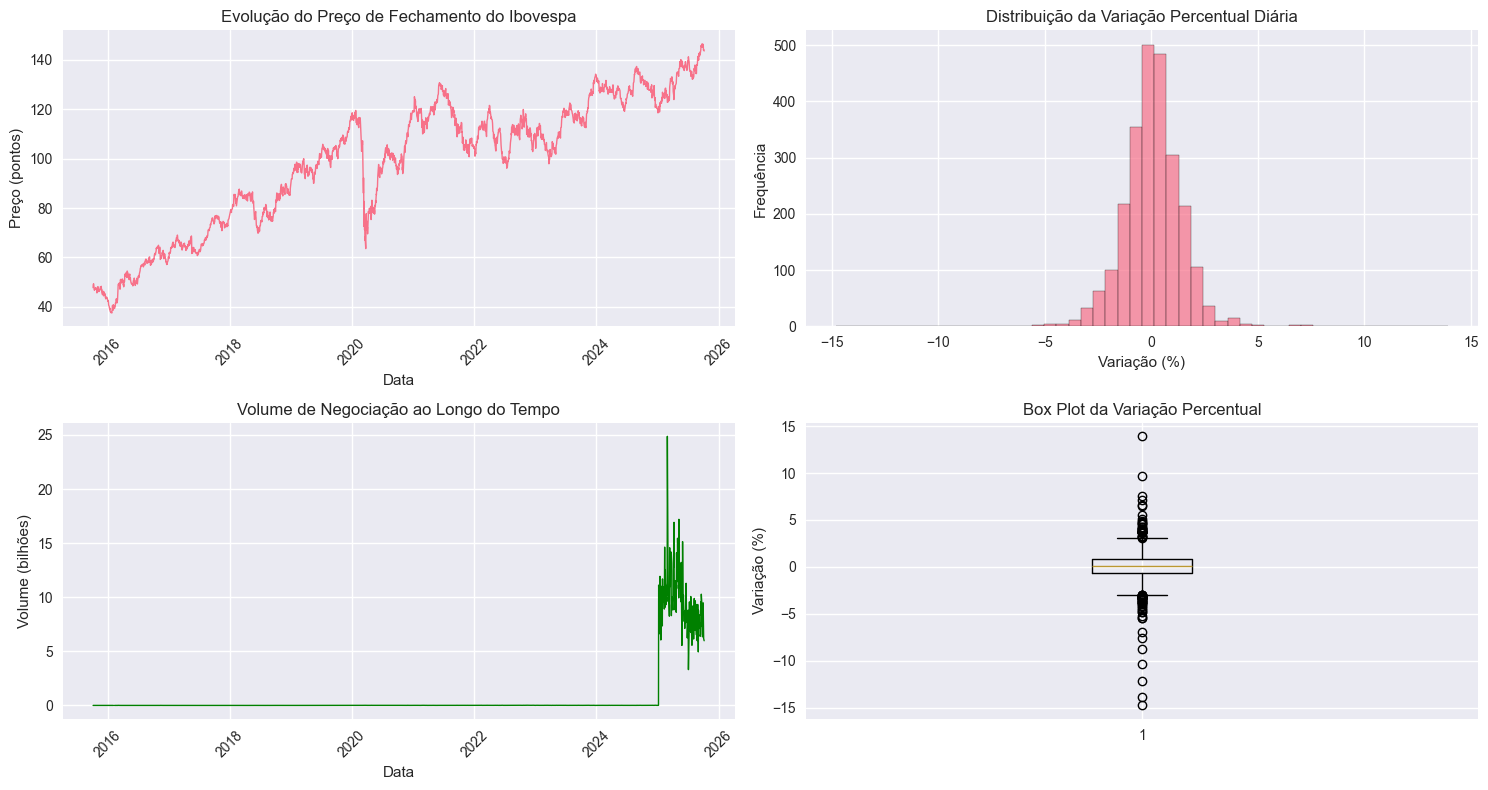

Estatísticas da Variação Percentual:
Média: 0.0556%
Mediana: 0.0700%
Desvio Padrão: 1.4829%
Mínimo: -14.7800%
Máximo: 13.9100%


In [4]:
# Análise Exploratória dos Dados (EDA)

# 1. Evolução temporal do preço de fechamento
plt.figure(figsize=(15, 8))
plt.subplot(2, 2, 1)
plt.plot(df['Data'], df['Último'], linewidth=1)
plt.title('Evolução do Preço de Fechamento do Ibovespa')
plt.xlabel('Data')
plt.ylabel('Preço (pontos)')
plt.xticks(rotation=45)

# 2. Distribuição da variação percentual
plt.subplot(2, 2, 2)
plt.hist(df['Var%'], bins=50, alpha=0.7, edgecolor='black')
plt.title('Distribuição da Variação Percentual Diária')
plt.xlabel('Variação (%)')
plt.ylabel('Frequência')

# 3. Volume de negociação ao longo do tempo
plt.subplot(2, 2, 3)
plt.plot(df['Data'], df['Vol.'], linewidth=1, color='green')
plt.title('Volume de Negociação ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Volume (bilhões)')
plt.xticks(rotation=45)

# 4. Box plot da variação percentual
plt.subplot(2, 2, 4)
plt.boxplot(df['Var%'])
plt.title('Box Plot da Variação Percentual')
plt.ylabel('Variação (%)')

plt.tight_layout()
plt.show()

# Estatísticas da variação percentual
print("Estatísticas da Variação Percentual:")
print(f"Média: {df['Var%'].mean():.4f}%")
print(f"Mediana: {df['Var%'].median():.4f}%")
print(f"Desvio Padrão: {df['Var%'].std():.4f}%")
print(f"Mínimo: {df['Var%'].min():.4f}%")
print(f"Máximo: {df['Var%'].max():.4f}%")


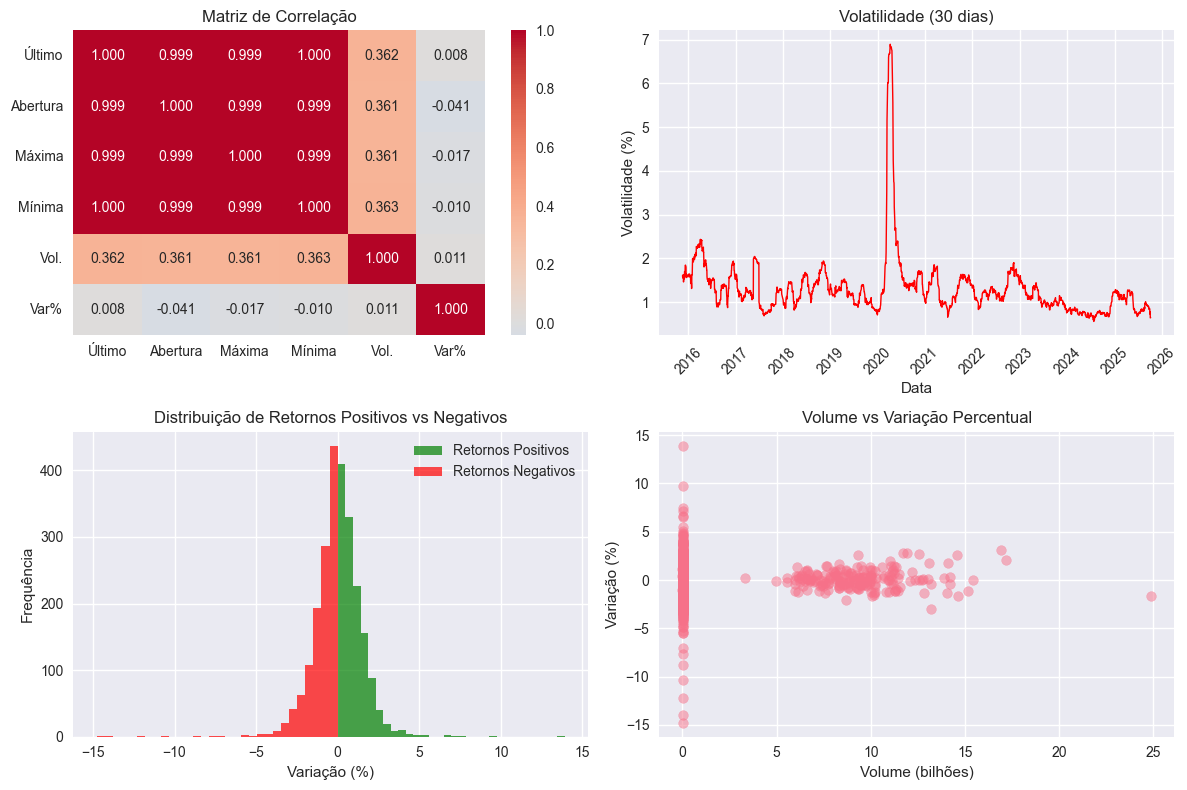

Análise de Retornos:
Total de dias: 2482
Dias com retorno positivo: 1302 (52.5%)
Dias com retorno negativo: 1174 (47.3%)
Dias sem variação: 6 (0.2%)


In [5]:
# Análise de correlações e padrões
plt.figure(figsize=(12, 8))

# Matriz de correlação
plt.subplot(2, 2, 1)
correlation_matrix = df[['Último', 'Abertura', 'Máxima', 'Mínima', 'Vol.', 'Var%']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Matriz de Correlação')

# Análise de volatilidade (desvio padrão móvel)
plt.subplot(2, 2, 2)
df['Volatilidade_30d'] = df['Var%'].rolling(window=30).std()
plt.plot(df['Data'], df['Volatilidade_30d'], linewidth=1, color='red')
plt.title('Volatilidade (30 dias)')
plt.xlabel('Data')
plt.ylabel('Volatilidade (%)')
plt.xticks(rotation=45)

# Distribuição de retornos positivos vs negativos
plt.subplot(2, 2, 3)
positive_returns = df[df['Var%'] > 0]['Var%']
negative_returns = df[df['Var%'] < 0]['Var%']
plt.hist(positive_returns, bins=30, alpha=0.7, label='Retornos Positivos', color='green')
plt.hist(negative_returns, bins=30, alpha=0.7, label='Retornos Negativos', color='red')
plt.title('Distribuição de Retornos Positivos vs Negativos')
plt.xlabel('Variação (%)')
plt.ylabel('Frequência')
plt.legend()

# Volume vs Variação
plt.subplot(2, 2, 4)
plt.scatter(df['Vol.'], df['Var%'], alpha=0.5)
plt.title('Volume vs Variação Percentual')
plt.xlabel('Volume (bilhões)')
plt.ylabel('Variação (%)')

plt.tight_layout()
plt.show()

# Estatísticas de retornos
print("Análise de Retornos:")
print(f"Total de dias: {len(df)}")
print(f"Dias com retorno positivo: {len(df[df['Var%'] > 0])} ({len(df[df['Var%'] > 0])/len(df)*100:.1f}%)")
print(f"Dias com retorno negativo: {len(df[df['Var%'] < 0])} ({len(df[df['Var%'] < 0])/len(df)*100:.1f}%)")
print(f"Dias sem variação: {len(df[df['Var%'] == 0])} ({len(df[df['Var%'] == 0])/len(df)*100:.1f}%)")


In [6]:
# Feature Engineering

# 1. Retornos históricos
df['Retorno_1d'] = df['Último'].pct_change(1) 
df['Retorno_5d'] = df['Último'].pct_change(5)
df["DirLag1"] = (df["Último"].shift(1) > df["Último"]).astype(int)

# 2. Médias móveis
df['MA_5'] = df['Último'].rolling(5).mean()
df['MA_20'] = df['Último'].rolling(20).mean()

# 3. Posição relativa à média móvel
df['Price_vs_MA20'] = ((df['Último'] - df['MA_20']) / df['MA_20']) * 100

# 4. Volatilidade
df['Volatilidade_10d'] = df['Último'].rolling(10).std()

# 5. RSI (Relative Strength Index)
def calculate_rsi(prices, window=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI_14'] = calculate_rsi(df['Último'])

# 6. MACD (Moving Average Convergence Divergence)
df['EMA_12'] = df['Último'].ewm(span=12).mean()
df['EMA_26'] = df['Último'].ewm(span=26).mean()
df['EMA_50'] = df['Último'].ewm(span=50).mean()
df['MACD'] = df['EMA_12'] - df['EMA_26']
df['Price_vs_EMA50'] = df['Último'] - df['EMA_50']

print("Feature Engineering concluído - APENAS 8 FEATURES SELECIONADAS")
print(f"Features criadas: Retorno_1d, Retorno_5d, MA_5, MA_20, Price_vs_MA20, Volatilidade_10d, RSI_14, MACD")
print(f"Total de features: 8")
print(f"Novo shape: {df.shape}")


Feature Engineering concluído - APENAS 8 FEATURES SELECIONADAS
Features criadas: Retorno_1d, Retorno_5d, MA_5, MA_20, Price_vs_MA20, Volatilidade_10d, RSI_14, MACD
Total de features: 8
Novo shape: (2482, 21)


In [7]:
# Criação da variável target
df['Retorno_Pct_Amanha'] = df['Último'].pct_change().shift(-1)
df['Target'] = (df['Retorno_Pct_Amanha'] > 0.005).astype(int)

print("Target criado: subida vs descida")
print(f"Threshold: 0.5% (em vez de 0%)")
print(f"Distribuição: {df['Target'].sum()} positivos ({df['Target'].mean()*100:.1f}%)")

# Removendo a última linha (não tem target)
df = df[:-1]

# Removendo linhas com valores NaN (devido às médias móveis)
df_clean = df.dropna().reset_index(drop=True)

print(f"Shape após limpeza: {df_clean.shape}")
print(f"Distribuição do target:")
print(df_clean['Target'].value_counts())
print(f"Percentual de subidas: {df_clean['Target'].mean()*100:.2f}%")
print(f"Percentual de descidas: {(1-df_clean['Target'].mean())*100:.2f}%")

feature_columns = [
    'Retorno_1d',      # Retorno de 1 dia
    'Retorno_5d',      # Retorno de 5 dias  
    'MA_5',            # Média móvel 5 dias
    'MA_20',           # Média móvel 20 dias
    'Price_vs_MA20',   # Posição relativa à MA20
    'RSI_14',          # RSI 14 períodos
    'MACD',            # MACD
    'Volatilidade_10d',# Volatilidade 10 dias
    'DirLag1',         # Direção ontem
    'Price_vs_EMA50',   # Média Movel 50 vs último 
]

# Verificando se todas as features existem
missing_features = [col for col in feature_columns if col not in df_clean.columns]
if missing_features:
    print(f"Features faltando: {missing_features}")
    # Removendo features que não existem
    feature_columns = [col for col in feature_columns if col in df_clean.columns]
    print(f"Features disponíveis: {feature_columns}")
# Verificando features disponíveis
print(f"\nFeatures disponíveis no dataset:")
available_features = [col for col in df_clean.columns if col not in ['Data', 'Último', 'Abertura', 'Máxima', 'Mínima', 'Vol.', 'Var%', 'Target', 'Retorno_Pct_Amanha']]
print(f"Total de features disponíveis: {len(available_features)}")
print(f"Features: {available_features}")

X = df_clean[feature_columns]
y = df_clean['Target']

print(f"\nNúmero de features selecionadas: {len(feature_columns)}")
print(f"Features selecionadas: {feature_columns}")
print(f"Distribuição do target com threshold de 0.5%:")
print(f"Subidas > 0.5%: {y.sum()} ({y.mean()*100:.2f}%)")
print(f"Subidas <= 0.5%: {(1-y).sum()} ({(1-y.mean())*100:.2f}%)")


Target criado: subida vs descida
Threshold: 0.5% (em vez de 0%)
Distribuição: 880 positivos (35.5%)
Shape após limpeza: (2451, 23)
Distribuição do target:
Target
0    1580
1     871
Name: count, dtype: int64
Percentual de subidas: 35.54%
Percentual de descidas: 64.46%

Features disponíveis no dataset:
Total de features disponíveis: 14
Features: ['Volatilidade_30d', 'Retorno_1d', 'Retorno_5d', 'DirLag1', 'MA_5', 'MA_20', 'Price_vs_MA20', 'Volatilidade_10d', 'RSI_14', 'EMA_12', 'EMA_26', 'EMA_50', 'MACD', 'Price_vs_EMA50']

Número de features selecionadas: 10
Features selecionadas: ['Retorno_1d', 'Retorno_5d', 'MA_5', 'MA_20', 'Price_vs_MA20', 'RSI_14', 'MACD', 'Volatilidade_10d', 'DirLag1', 'Price_vs_EMA50']
Distribuição do target com threshold de 0.5%:
Subidas > 0.5%: 871 (35.54%)
Subidas <= 0.5%: 1580 (64.46%)


In [8]:
# Divisão dos dados
split_index = len(X) - 30
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Divisão dos dados:")
print(f"Treino: {len(X_train)} amostras ({len(X_train)/len(X)*100:.1f}%)")
print(f"Teste: {len(X_test)} amostras ({len(X_test)/len(X)*100:.1f}%)")

# Verificando distribuição do target em treino e teste
print(f"\nDistribuição do target:")
print(f"Treino - Subidas: {y_train.mean()*100:.2f}% | ({y_train.sum()} positivos / {len(y_train)} total)")
print(f"Teste - Subidas: {y_test.mean()*100:.2f}% | ({y_test.sum()} positivos / {len(y_test)} total)")
print(f"Escala das classes: {np.sqrt((y_test == 0).sum()/(y_test == 1).sum())}")

# Normalização das features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nDados preparados para modelagem")
print(f"Features de treino: {X_train_scaled.shape}")
print(f"Features de teste: {X_test_scaled.shape}")


Divisão dos dados:
Treino: 2421 amostras (98.8%)
Teste: 30 amostras (1.2%)

Distribuição do target:
Treino - Subidas: 35.56% | (861 positivos / 2421 total)
Teste - Subidas: 33.33% | (10 positivos / 30 total)
Escala das classes: 1.4142135623730951

Dados preparados para modelagem
Features de treino: (2421, 10)
Features de teste: (30, 10)


In [9]:
# Verificação dos dados
print(f"Shape dos dados: {df_clean.shape}")
print(f"Distribuição do target:")
print(f"  Classe 0: {(y == 0).sum()} ({(y == 0).mean()*100:.1f}%)")
print(f"  Classe 1: {(y == 1).sum()} ({(y == 1).mean()*100:.1f}%)")
print(f"\nDivisão treino/teste:")
print(f"  Treino: {len(X_train)} amostras")
print(f"  Teste: {len(X_test)} amostras")
print(f"  Target treino - Classe 1: {y_train.mean()*100:.1f}%")
print(f"  Target teste - Classe 1: {y_test.mean()*100:.1f}%")

print(f"\nFeatures utilizadas:")
for i, col in enumerate(feature_columns):
    print(f"  {i+1}. {col}")


Shape dos dados: (2451, 23)
Distribuição do target:
  Classe 0: 1580 (64.5%)
  Classe 1: 871 (35.5%)

Divisão treino/teste:
  Treino: 2421 amostras
  Teste: 30 amostras
  Target treino - Classe 1: 35.6%
  Target teste - Classe 1: 33.3%

Features utilizadas:
  1. Retorno_1d
  2. Retorno_5d
  3. MA_5
  4. MA_20
  5. Price_vs_MA20
  6. RSI_14
  7. MACD
  8. Volatilidade_10d
  9. DirLag1
  10. Price_vs_EMA50


In [10]:
# Modelo XGBoost
print("MODELO XGBOOST")

# Treinamento do XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=93,
    class_pos_weight=660
)

# Treinamento
xgb_model.fit(X_train_scaled, y_train)

# Predições
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

prec, rec, thr = precision_recall_curve(y_test, y_pred_proba_xgb)
f1_scores = 2 * prec * rec / (prec + rec)

best_idx = np.argmax(f1_scores)
best_threshold = thr[best_idx]

print(f"\nMelhor threshold: {best_threshold:.8f}")

y_pred_xgb = (y_pred_proba_xgb >= best_threshold).astype(int)

# Avaliação
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Acurácia XGBoost: {accuracy_xgb:.4f} ({accuracy_xgb*100:.2f}%)")

# Relatório de classificação
print("\nRelatório de Classificação XGBoost:")
print(classification_report(y_test, y_pred_xgb))

# Matriz de confusão
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(f"\nMatriz de Confusão XGBoost:")
print(cm_xgb)

# Validação cruzada temporal
tscv = TimeSeriesSplit(n_splits=5)
cv_scores_xgb = cross_val_score(xgb_model, X_train_scaled, y_train, cv=tscv, scoring='accuracy')
print(f"\nValidação Cruzada Temporal XGBoost (5 folds):")
print(f"Média: {cv_scores_xgb.mean():.4f} ({cv_scores_xgb.mean()*100:.2f}%)")
print(f"Desvio Padrão: {cv_scores_xgb.std():.4f}")
print(f"Scores por fold: {cv_scores_xgb}")

# Importância das features
feature_importance_xgb = pd.DataFrame({
    'feature': feature_columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 10 Features mais importantes (XGBoost):")
print(feature_importance_xgb.head(10))

MODELO XGBOOST

Melhor threshold: 0.11238790
Acurácia XGBoost: 0.7667 (76.67%)

Relatório de Classificação XGBoost:
              precision    recall  f1-score   support

           0       0.88      0.75      0.81        20
           1       0.62      0.80      0.70        10

    accuracy                           0.77        30
   macro avg       0.75      0.78      0.75        30
weighted avg       0.79      0.77      0.77        30


Matriz de Confusão XGBoost:
[[15  5]
 [ 2  8]]

Validação Cruzada Temporal XGBoost (5 folds):
Média: 0.6084 (60.84%)
Desvio Padrão: 0.0491
Scores por fold: [0.61290323 0.57320099 0.57816377 0.57568238 0.70223325]

Top 10 Features mais importantes (XGBoost):
            feature  importance
2              MA_5    0.111557
3             MA_20    0.108765
7  Volatilidade_10d    0.108407
9    Price_vs_EMA50    0.108050
6              MACD    0.107279
0        Retorno_1d    0.107032
1        Retorno_5d    0.106791
5            RSI_14    0.099560
4     Pric

In [11]:
# Modelo Random Forest com Grid Search
print("\nMODELO RANDOM FOREST COM GRID SEARCH")

# Grid Search expandido para melhor otimização
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None],
    'max_features': ['sqrt', 'log2', None],
}

from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print(f"Melhores parâmetros: {grid.best_params_}")
print(f"Melhor score: {grid.best_score_:.4f}")

# Salvando os melhores parâmetros para usar na próxima célula
best_params = grid.best_params_


MODELO RANDOM FOREST COM GRID SEARCH
Melhores parâmetros: {'class_weight': None, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
Melhor score: 0.6150


In [12]:
# Treinamento do modelo Random Forest final com os melhores parâmetros
print("\nTREINAMENTO DO MODELO RANDOM FOREST FINAL")

# Usando os melhores parâmetros encontrados pelo GridSearch
rf_model = RandomForestClassifier(**best_params, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predições
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

prec, rec, thr = precision_recall_curve(y_test, y_pred_proba_rf)
f1_scores = 2 * prec * rec / (prec + rec)

best_idx = np.argmax(f1_scores)
best_threshold = thr[best_idx]

print(f"\nMelhor threshold: {best_threshold:.3f}")

y_pred_rf = (y_pred_proba_rf >= best_threshold).astype(int)

# Avaliação
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Acurácia Random Forest: {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")

# Relatório de classificação
print("\nRelatório de Classificação Random Forest:")
print(classification_report(y_test, y_pred_rf))

# Matriz de confusão
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"\nMatriz de Confusão Random Forest:")
print(cm_rf)

# Validação cruzada temporal
tscv = TimeSeriesSplit(n_splits=5)
cv_scores_rf = cross_val_score(rf_model, X_train_scaled, y_train, cv=tscv, scoring='accuracy')
print(f"\nValidação Cruzada Temporal Random Forest (5 folds):")
print(f"Média: {cv_scores_rf.mean():.4f} ({cv_scores_rf.mean()*100:.2f}%)")
print(f"Desvio Padrão: {cv_scores_rf.std():.4f}")
print(f"Scores por fold: {cv_scores_rf}")

# Importância das features - Random Forest
feature_importance_rf = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 10 Features mais importantes (Random Forest):")
print(feature_importance_rf.head(10))



TREINAMENTO DO MODELO RANDOM FOREST FINAL

Melhor threshold: 0.216
Acurácia Random Forest: 0.5000 (50.00%)

Relatório de Classificação Random Forest:
              precision    recall  f1-score   support

           0       0.86      0.30      0.44        20
           1       0.39      0.90      0.55        10

    accuracy                           0.50        30
   macro avg       0.62      0.60      0.49        30
weighted avg       0.70      0.50      0.48        30


Matriz de Confusão Random Forest:
[[ 6 14]
 [ 1  9]]

Validação Cruzada Temporal Random Forest (5 folds):
Média: 0.6541 (65.41%)
Desvio Padrão: 0.0471
Scores por fold: [0.65012407 0.60545906 0.62282878 0.65012407 0.74193548]

Top 10 Features mais importantes (Random Forest):
            feature  importance
2              MA_5    0.198307
3             MA_20    0.156904
0        Retorno_1d    0.140337
1        Retorno_5d    0.115441
9    Price_vs_EMA50    0.112961
4     Price_vs_MA20    0.075508
5            RSI_14  

In [18]:
print("\nMODELO KNEIGHBORS - RANDOMIZED SEARCH")

from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import randint

# Modelo base
KNeigh = KNeighborsClassifier()

# Parâmetros para Random Search
param_dist = {
    'n_neighbors': randint(1, 60),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

# Rodando o Randomized Search
random_knb = RandomizedSearchCV(
    KNeigh,
    param_distributions=param_dist,
    n_iter=20,  # número de combinações aleatórias testadas
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=90
)
random_knb.fit(X_train_scaled, y_train)

KNeigh = random_knb.best_estimator_

print(f"Melhores parâmetros (Randomized): {random_knb.best_params_}")
print(f"Melhor score (validação): {random_knb.best_score_:.4f}")

# Predições
y_pred_proba_KNB = KNeigh.predict_proba(X_test_scaled)[:, 1]
y_pred_KNB = KNeigh.predict(X_test_scaled)

prec, rec, thr = precision_recall_curve(y_test, y_pred_proba_KNB)
f1_scores = 2 * prec * rec / (prec + rec)
best_idx = np.argmax(f1_scores)
best_threshold = thr[best_idx]

print(f"\nMelhor threshold: {best_threshold:.3f}")

y_pred_KNB = (y_pred_proba_KNB >= best_threshold).astype(int)

# Avaliação
accuracy_knb = accuracy_score(y_test, y_pred_KNB)
print(f"Acurácia KNeighbors: {accuracy_knb:.4f} ({accuracy_knb*100:.2f}%)")

print("\nRelatório de Classificação KNeighbors:")
print(classification_report(y_test, y_pred_KNB))

# Matriz de confusão
cm_rf = confusion_matrix(y_test, y_pred_KNB)
print(f"\nMatriz de Confusão KNeighbors:")
print(cm_rf)

# Validação cruzada temporal
tscv = TimeSeriesSplit(n_splits=5)
cv_scores_knb = cross_val_score(KNeigh, X_train_scaled, y_train, cv=tscv, scoring='accuracy')
print(f"\nValidação Cruzada Temporal KNeighbors (5 folds):")
print(f"Média: {cv_scores_knb.mean():.4f} ({cv_scores_knb.mean()*100:.2f}%)")
print(f"Desvio Padrão: {cv_scores_knb.std():.4f}")
print(f"Scores por fold: {cv_scores_knb}")


MODELO KNEIGHBORS - RANDOMIZED SEARCH
Melhores parâmetros (Randomized): {'metric': 'euclidean', 'n_neighbors': 58, 'p': 2, 'weights': 'uniform'}
Melhor score (validação): 0.6353

Melhor threshold: 0.310
Acurácia KNeighbors: 0.5333 (53.33%)

Relatório de Classificação KNeighbors:
              precision    recall  f1-score   support

           0       0.62      0.80      0.70        20
           1       0.00      0.00      0.00        10

    accuracy                           0.53        30
   macro avg       0.31      0.40      0.35        30
weighted avg       0.41      0.53      0.46        30


Matriz de Confusão KNeighbors:
[[16  4]
 [10  0]]

Validação Cruzada Temporal KNeighbors (5 folds):
Média: 0.6531 (65.31%)
Desvio Padrão: 0.0490
Scores por fold: [0.65260546 0.59801489 0.62034739 0.65260546 0.74193548]


In [21]:
# Comparação dos Modelos
print("COMPARAÇÃO DOS MODELOS")

# Criando DataFrame com resultados
results_df = pd.DataFrame({
    'Modelo': ['XGBoost', 'Random Forest', 'KNEIGHBORS'],
    'Acurácia': [accuracy_xgb, accuracy_rf, accuracy_knb],
    'Acurácia_%': [accuracy_xgb*100, accuracy_rf*100, accuracy_knb*100],
    'CV_Score': [cv_scores_xgb.mean(), cv_scores_rf.mean(), cv_scores_knb.mean()],
    'CV_Score_%': [cv_scores_xgb.mean()*100, cv_scores_rf.mean()*100, cv_scores_knb.mean()*100],
    'CV_Std': [cv_scores_xgb.std(), cv_scores_rf.std(), cv_scores_knb.std()]
})

print("Resultados dos Modelos:")
print(results_df.round(4))

# Verificando se atingiu o objetivo de 75%
print(f"\nObjetivo: Atingir pelo menos 75% de precisão")
print(f"XGBoost: {'ATINGIU' if accuracy_xgb >= 0.75 else 'NÃO ATINGIU'} ({accuracy_xgb*100:.2f}%)")
print(f"Random Forest: {'ATINGIU' if accuracy_rf >= 0.75 else 'NÃO ATINGIU'} ({accuracy_rf*100:.2f}%)")
print(f"KNEIGHBORS: {'ATINGIU' if accuracy_knb >= 0.75 else 'NÃO ATINGIU'} ({accuracy_knb*100:.2f}%)")

# Melhor modelo
best_accuracy = max(accuracy_xgb, accuracy_rf, accuracy_knb)
if best_accuracy == accuracy_xgb:
    best_model = 'XGBoost'
elif best_accuracy == accuracy_rf:
    best_model = 'Random Forest'
else:
    best_model = 'KNEIGHBORS'

print(f"\nMelhor modelo: {best_model} com {best_accuracy*100:.2f}% de acurácia")

# Análise de performance por classe
from sklearn.metrics import precision_score, recall_score, f1_score

print(f"\nMétricas detalhadas:")
print(f"XGBoost - Precision: {precision_score(y_test, y_pred_xgb):.4f}, Recall: {recall_score(y_test, y_pred_xgb):.4f}, F1: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"Random Forest - Precision: {precision_score(y_test, y_pred_rf):.4f}, Recall: {recall_score(y_test, y_pred_rf):.4f}, F1: {f1_score(y_test, y_pred_rf):.4f}")
print(f"KNEIGHBORS: {precision_score(y_test, y_pred_KNB):.4f}, Recall: {recall_score(y_test, y_pred_KNB):.4f}, F1: {f1_score(y_test, y_pred_KNB):.4f}")


COMPARAÇÃO DOS MODELOS
Resultados dos Modelos:
          Modelo  Acurácia  Acurácia_%  CV_Score  CV_Score_%  CV_Std
0        XGBoost    0.7667     76.6667    0.6084     60.8437  0.0491
1  Random Forest    0.5000     50.0000    0.6541     65.4094  0.0471
2     KNEIGHBORS    0.5333     53.3333    0.6531     65.3102  0.0490

Objetivo: Atingir pelo menos 75% de precisão
XGBoost: ATINGIU (76.67%)
Random Forest: NÃO ATINGIU (50.00%)
KNEIGHBORS: NÃO ATINGIU (53.33%)

Melhor modelo: XGBoost com 76.67% de acurácia

Métricas detalhadas:
XGBoost - Precision: 0.6154, Recall: 0.8000, F1: 0.6957
Random Forest - Precision: 0.3913, Recall: 0.9000, F1: 0.5455
KNEIGHBORS: 0.0000, Recall: 0.0000, F1: 0.0000


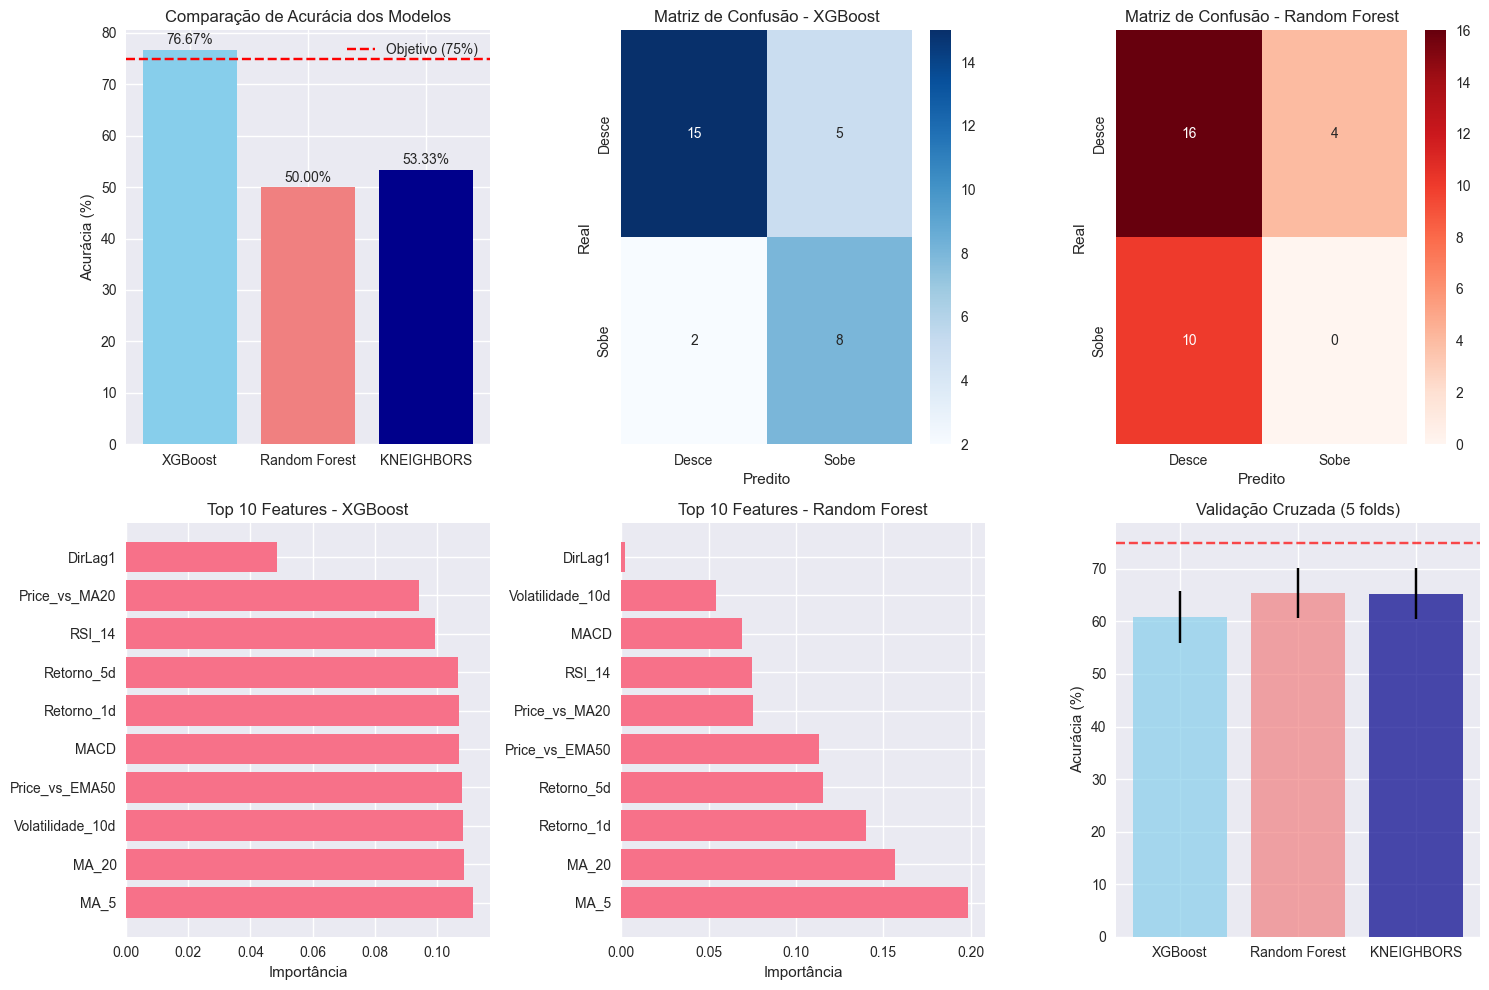

In [24]:
# Visualizações dos Resultados

# 1. Comparação de Acurácia
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
models = ['XGBoost', 'Random Forest', 'KNEIGHBORS']
accuracies = [accuracy_xgb*100, accuracy_rf*100, accuracy_knb*100]
colors = ['skyblue', 'lightcoral', 'darkblue']
bars = plt.bar(models, accuracies, color=colors)
plt.title('Comparação de Acurácia dos Modelos')
plt.ylabel('Acurácia (%)')
plt.axhline(y=75, color='red', linestyle='--', label='Objetivo (75%)')
plt.legend()

# Adicionando valores nas barras
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{acc:.2f}%', ha='center', va='bottom')

# 2. Matriz de Confusão - XGBoost
plt.subplot(2, 3, 2)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Desce', 'Sobe'], yticklabels=['Desce', 'Sobe'])
plt.title('Matriz de Confusão - XGBoost')
plt.ylabel('Real')
plt.xlabel('Predito')

# 3. Matriz de Confusão - Random Forest
plt.subplot(2, 3, 3)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Desce', 'Sobe'], yticklabels=['Desce', 'Sobe'])
plt.title('Matriz de Confusão - Random Forest')
plt.ylabel('Real')
plt.xlabel('Predito')

# 4. Importância das Features - XGBoost
plt.subplot(2, 3, 4)
top_features_xgb = feature_importance_xgb.head(10)
plt.barh(range(len(top_features_xgb)), top_features_xgb['importance'])
plt.yticks(range(len(top_features_xgb)), top_features_xgb['feature'])
plt.title('Top 10 Features - XGBoost')
plt.xlabel('Importância')

# 5. Importância das Features - Random Forest
plt.subplot(2, 3, 5)
top_features_rf = feature_importance_rf.head(10)
plt.barh(range(len(top_features_rf)), top_features_rf['importance'])
plt.yticks(range(len(top_features_rf)), top_features_rf['feature'])
plt.title('Top 10 Features - Random Forest')
plt.xlabel('Importância')

# 6. Comparação de Validação Cruzada
plt.subplot(2, 3, 6)
cv_means = [cv_scores_xgb.mean()*100, cv_scores_rf.mean()*100, cv_scores_knb.mean()*100]
cv_stds = [cv_scores_xgb.std()*100, cv_scores_rf.std()*100, cv_scores_knb.std()*100]
x_pos = np.arange(len(models))
plt.bar(x_pos, cv_means, yerr=cv_stds, capsize=5, color=colors, alpha=0.7)
plt.title('Validação Cruzada (5 folds)')
plt.ylabel('Acurácia (%)')
plt.xticks(x_pos, models)
plt.axhline(y=75, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


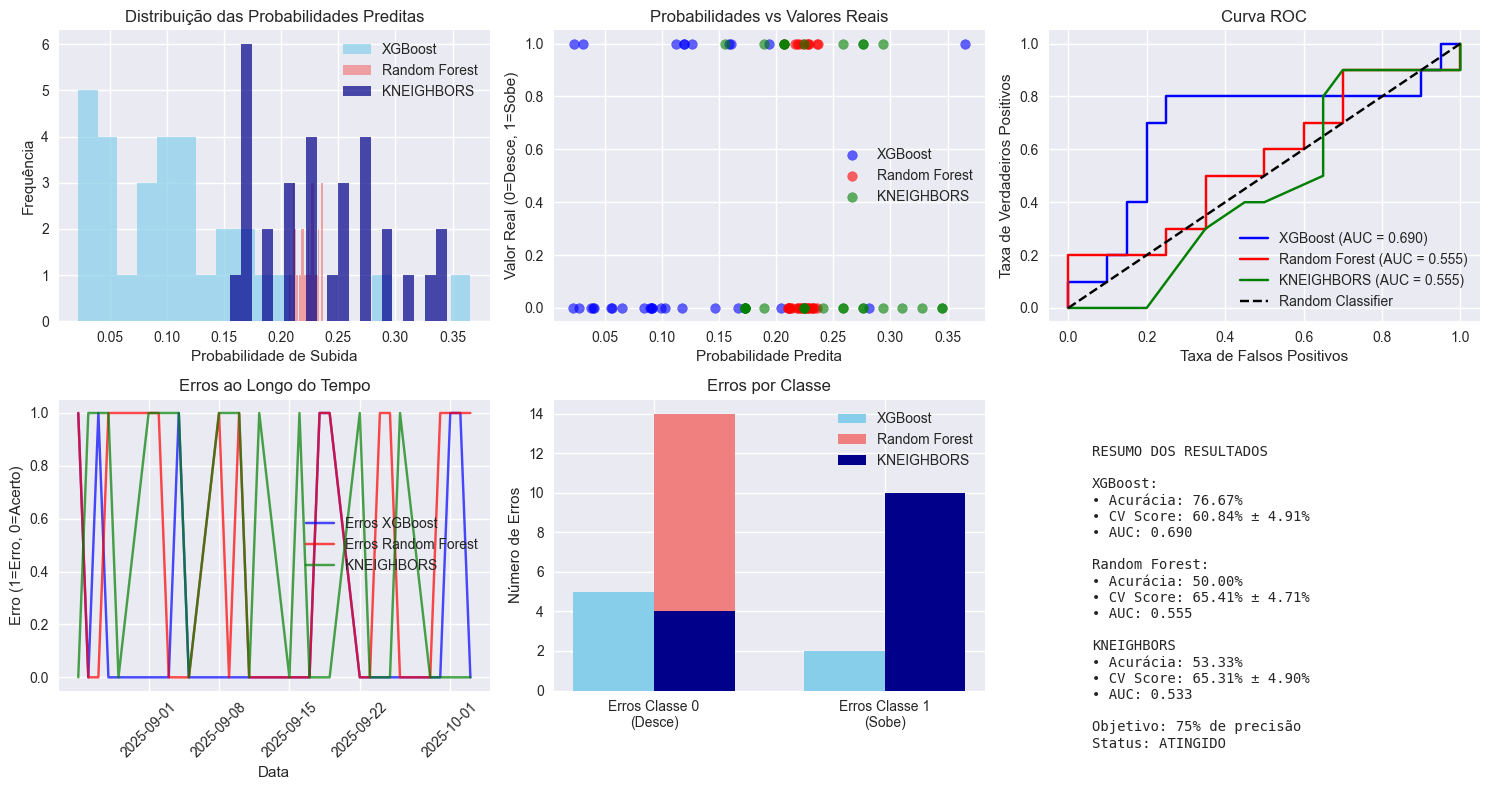

In [26]:
# Análise de Predições e Probabilidades
plt.figure(figsize=(15, 8))

# 1. Distribuição das probabilidades preditas
plt.subplot(2, 3, 1)
plt.hist(y_pred_proba_xgb, bins=20, alpha=0.7, label='XGBoost', color='skyblue')
plt.hist(y_pred_proba_rf, bins=20, alpha=0.7, label='Random Forest', color='lightcoral')
plt.hist(y_pred_proba_KNB, bins=20, alpha=0.7, label='KNEIGHBORS', color='darkblue')
plt.title('Distribuição das Probabilidades Preditas')
plt.xlabel('Probabilidade de Subida')
plt.ylabel('Frequência')
plt.legend()

# 2. Scatter plot: Probabilidades vs Real
plt.subplot(2, 3, 2)
plt.scatter(y_pred_proba_xgb, y_test, alpha=0.6, label='XGBoost', color='blue')
plt.scatter(y_pred_proba_rf, y_test, alpha=0.6, label='Random Forest', color='red')
plt.scatter(y_pred_proba_KNB, y_test, alpha=0.6, label='KNEIGHBORS', color='green')
plt.title('Probabilidades vs Valores Reais')
plt.xlabel('Probabilidade Predita')
plt.ylabel('Valor Real (0=Desce, 1=Sobe)')
plt.legend()

# 3. ROC Curve (simplificada)
from sklearn.metrics import roc_curve, auc

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_KNB, tpr_KNB, _ = roc_curve(y_test, y_pred_proba_KNB)
auc_xgb = auc(fpr_xgb, tpr_xgb)
auc_rf = auc(fpr_rf, tpr_rf)
aux_KNB = auc(fpr_KNB, tpr_KNB)
plt.subplot(2, 3, 3)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})', color='blue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='red')
plt.plot(fpr_KNB, tpr_KNB, label=f'KNEIGHBORS (AUC = {auc_rf:.3f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title('Curva ROC')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.legend()

# 4. Análise de erros por período
plt.subplot(2, 3, 4)
test_dates = df_clean['Data'].iloc[split_index:].reset_index(drop=True)
errors_xgb = (y_test != y_pred_xgb).astype(int)
errors_rf = (y_test != y_pred_rf).astype(int)
errors_KNB = (y_test != y_pred_KNB).astype(int)

plt.plot(test_dates, errors_xgb, alpha=0.7, label='Erros XGBoost', color='blue')
plt.plot(test_dates, errors_rf, alpha=0.7, label='Erros Random Forest', color='red')
plt.plot(test_dates, errors_KNB, alpha=0.7, label='KNEIGHBORS', color='green')
plt.title('Erros ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Erro (1=Erro, 0=Acerto)')
plt.xticks(rotation=45)
plt.legend()

# 5. Comparação de performance por classe
plt.subplot(2, 3, 5)
class_0_errors_xgb = ((y_test == 0) & (y_pred_xgb != 0)).sum()
class_1_errors_xgb = ((y_test == 1) & (y_pred_xgb != 1)).sum()
class_0_errors_rf = ((y_test == 0) & (y_pred_rf != 0)).sum()
class_1_errors_rf = ((y_test == 1) & (y_pred_rf != 1)).sum()
class_0_errors_KNB = ((y_test == 0) & (y_pred_KNB != 0)).sum()
class_1_errors_KNB = ((y_test == 1) & (y_pred_KNB != 1)).sum()

categories = ['Erros Classe 0\n(Desce)', 'Erros Classe 1\n(Sobe)']
xgb_errors = [class_0_errors_xgb, class_1_errors_xgb]
rf_errors = [class_0_errors_rf, class_1_errors_rf]
KNB_errors = [class_0_errors_KNB, class_1_errors_KNB]

x = np.arange(len(categories))
width = 0.35

plt.bar(x - width/2, xgb_errors, width, label='XGBoost', color='skyblue')
plt.bar(x + width/2, rf_errors, width, label='Random Forest', color='lightcoral')
plt.bar(x + width/2, KNB_errors, width, label='KNEIGHBORS', color='darkblue')
plt.title('Erros por Classe')
plt.ylabel('Número de Erros')
plt.xticks(x, categories)
plt.legend()

# 6. Resumo final
plt.subplot(2, 3, 6)
plt.axis('off')
summary_text = f"""
RESUMO DOS RESULTADOS

XGBoost:
• Acurácia: {accuracy_xgb*100:.2f}%
• CV Score: {cv_scores_xgb.mean()*100:.2f}% ± {cv_scores_xgb.std()*100:.2f}%
• AUC: {auc_xgb:.3f}

Random Forest:
• Acurácia: {accuracy_rf*100:.2f}%
• CV Score: {cv_scores_rf.mean()*100:.2f}% ± {cv_scores_rf.std()*100:.2f}%
• AUC: {auc_rf:.3f}

KNEIGHBORS
• Acurácia: {accuracy_knb*100:.2f}%
• CV Score: {cv_scores_knb.mean()*100:.2f}% ± {cv_scores_knb.std()*100:.2f}%
• AUC: {accuracy_knb:.3f}

Objetivo: 75% de precisão
Status: {'ATINGIDO' if max(accuracy_xgb, accuracy_rf) >= 0.75 else 'NÃO ATINGIDO'}
"""
plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', fontfamily='monospace')

plt.tight_layout()
plt.show()
